# Flow Matching: SU3 gauge theory on $4^4$ lattice

*Sep 24, 2025*

**[Javad Komijani (ETH Zurich)](mailto:jkomijani@gmail.com)**

# Example: SU(3)

In [1]:
import torch
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

In [2]:
from lattice_ml.gauge_tools import WilsonGaugeAction, GaugeLinkConv, UNet, UNetEncoderLayer, UNetBottleneck, UNetDecoderLayer

from normflow.prior import SUnPrior

## Dynamics function

The flow is defined as
$$
   \frac{dU_t}{dt} = f(U_t) U_t
$$
where $f(U_t)$ is in the algebra space of the group.
We call $f(U_t)$ the algbra dynamcis functions.

We now give a simple neural networ for the algebra dynamics functions.

In [3]:
action = WilsonGaugeAction(beta=6)

def make_unet(spatial_ndim=4):
    """An example showing how to make an instance of UNet."""

    kwargs = {"spatial_ndim": spatial_ndim}

    # Encoding (contractive) path
    encoder_layers = [
        UNetEncoderLayer(channels=(1, 2), **kwargs),
    ]

    # bottleneck
    bottleneck = UNetBottleneck(channels=(2, 2), **kwargs)

    # Decoding (expansive) path
    decoder_layers = [
        UNetDecoderLayer(channels=(2, 1), **kwargs),
    ]

    return UNet(encoder_layers, bottleneck, decoder_layers)

class SimpleAlgDynamcisFunc(torch.nn.Module):
    """Algebra dynamcis function for SU(3) matrices.

    This model takes as input the time `t` and the initial state matrix `x` and
    predicts a flow while ensuring the output remains antihermitian and traceless.
    """

    def __init__(self, in_channels=None, out_channels= None, ndim=4):
        """Initializes the SU3DynamicsFunc neural network."""
        super().__init__()
        
        self.weight = torch.nn.Parameter(torch.rand(5) * 3 / 16)
        self.powers = torch.arange(5).reshape(1, -1)
        self.unet = make_unet()
        
    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """Computes the forward pass of the SU3 flow function.

        Given a time `t` and a matrix `x`, the function processes the input
        through the neural network and applies post-processing to ensure the
        output is antihermitian and traceless.

        Args:
            - t (torch.Tensor): A 0D or 1D tensor representing time.
              If 1D, it is of shape (batch_size,)
            - x (torch.Tensor): A complex-valued input tensor of shape
              (batch_size, 1, 3, 3).

        Returns:
            - torch.Tensor: A antihermitian, traceless tensor of shape
              (batch_size, 1, 3, 3).
        """
        shape = (-1, *[1]*(x.ndim - 1))
        x = self.unet(x, time=t)
        return x * self.time_func(t).reshape(*shape)
    
    def time_func(self, t):
        return torch.sum(self.weight * t.unsqueeze(-1) ** self.powers, dim=1)


In [4]:
training_samples = torch.load("/scratch/lturgut/cfgs_b6_200traj_15steps.pt", map_location="cuda:0")

from torch.utils.data import DataLoader, TensorDataset

batch_size = 256 // 4

dataset = TensorDataset(training_samples)

data_loader1 = DataLoader(
    dataset,
    batch_size = batch_size,
    shuffle = False
)

In [5]:
from lattice_ml.flow_matching import make_random_dataloader

num_samples, *sample_shape, n_c, n_c = training_samples.shape

prior = SUnPrior(n_c, sample_shape)

data_loader0 = make_random_dataloader(
    prior, batch_size, num_batches=num_samples//batch_size
)

In [6]:
from functools import partial

n_epochs = 100

train_kwargs = dict(
    n_epochs = n_epochs,
    hyperparam = dict(lr=0.003),
    checkpoint_dict = dict(print_every=20),
    scheduler = partial(
        torch.optim.lr_scheduler.CosineAnnealingLR,                     
        T_max = int(1.01 * n_epochs)                                    
    )
)

In [ ]:
from lattice_ml.flow_matching import LieTrainer

algebra_dynamics_fn = SimpleAlgDynamcisFunc()

trainer = LieTrainer(algebra_dynamics_fn)

trainer.execute(data_loader0, data_loader1, **train_kwargs)

15:51:13 | Training started for 100 epochs


Text(0, 0.5, 'Loss')

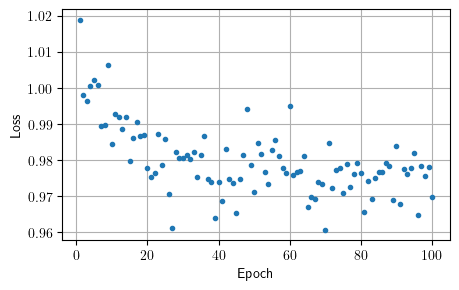

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(5, 3))

loss = trainer.train_history['loss']
epochs = np.arange(1, len(loss) + 1)
plt.plot(epochs, loss, '.')

plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Loss")

In [ ]:
from lattice_ml.gauge_tools import compute_avg_trace_wilson_mxn_loop

from lattice_ml.integrate import lie_odeint

In [ ]:
x = prior.sample(16)

dynamics_fn = lambda t, y: algebra_dynamics_fn(t, y) @ y

with torch.no_grad():
    y = lie_odeint(dynamics_fn, t_span=(0, 1), y0=x, num_steps=100)

In [ ]:
(compute_avg_trace_wilson_mxn_loop(training_samples, 1, 1).mean(),
 compute_avg_trace_wilson_mxn_loop(y, 1, 1).mean(),
 compute_avg_trace_wilson_mxn_loop(y, 1, 1).std()
)

(tensor(0.5965, device='cuda:0'),
 tensor(0.3785, device='cuda:0'),
 tensor(0.0052, device='cuda:0'))

In [ ]:
algebra_dynamics_fn.weight * 16 / 3

tensor([-0.1429,  1.1659,  0.9717,  0.3620,  0.6271], device='cuda:0',
       grad_fn=<DivBackward0>)

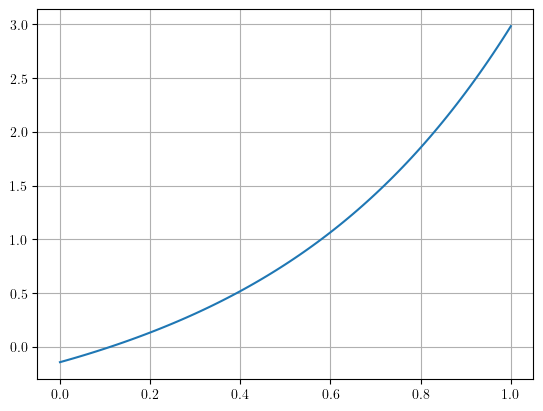

In [ ]:
grab = lambda x: x.detach().cpu().numpy()
t = torch.linspace(0, 1, 101)
z = 16 / 3 * algebra_dynamics_fn.time_func(t)

with torch.no_grad():
    plt.plot(grab(t), grab(z))

plt.grid()

In [ ]:
from lattice_ml.gauge_tools import compute_wilson_1x1_loop

print(y.shape)
theta_x = torch.linalg.eig(compute_wilson_1x1_loop(x, 0, 1))[0].angle()
theta_y = torch.linalg.eig(compute_wilson_1x1_loop(y, 0, 1))[0].angle()

theta_test = torch.linalg.eig(compute_wilson_1x1_loop(training_samples, 0, 1))[0].angle()

torch.Size([16, 4, 4, 4, 4, 4, 3, 3])


In [ ]:
grab = lambda x: x.detach().cpu().numpy()

theta_x = grab(theta_x)
theta_y = grab(theta_y)

theta_test = np.array([grab(q) for q in theta_test])

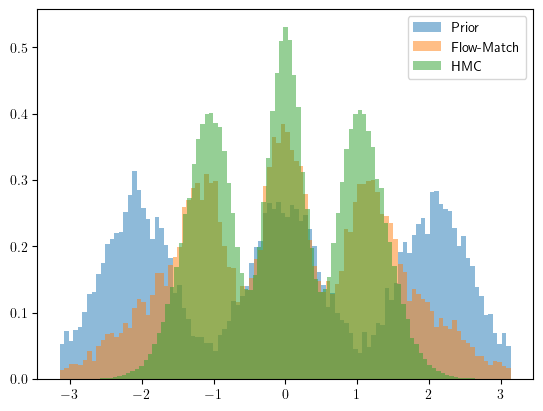

In [ ]:
plt.hist(theta_x.ravel(), label = 'Prior', bins=100, density=True, alpha=0.5)
plt.hist(theta_y.ravel(), label = 'Flow-Match', bins=100, density=True, alpha=0.5)
plt.hist(theta_test.ravel(), label = 'HMC', bins=100, density=True, alpha=0.5)

plt.legend();

## Visualize the flow of eigen-angles of Wilson 1x1 loops

In [ ]:
from lattice_ml.functions import pow_special_unitary_group

In [ ]:
u_0 = prior.sample(num_samples).unsqueeze(1)  # axis 1: simulation time
u_1 = training_samples.unsqueeze(1)  # axis: simulation time


t_eval = np.linspace(0, 1, 100)

# Note that t must be broadcastable to eigenvalues of u_0 & u_1 matrices
t = torch.from_numpy(t_eval).reshape(1, -1, *(1,)*(u_0.ndim - 3))

t = t.to(device='cuda')
print(t.device)

print(u_1.device)
u_t = pow_special_unitary_group(u_1 @ u_0.adjoint(), t) @ u_0

cuda:0
cuda:0


OutOfMemoryError: CUDA out of memory. Tried to allocate 3.52 GiB. GPU 0 has a total capacity of 11.90 GiB of which 3.26 GiB is free. Including non-PyTorch memory, this process has 8.63 GiB memory in use. Of the allocated memory 8.39 GiB is allocated by PyTorch, and 27.08 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
from lattice_ml.linalg import eigu


w1x1_u_t = compute_wilson_1x1_loop(u_t, 0, 1, prefix_dims=2)

theta = eigu(w1x1_u_t)[0].angle().movedim(0, 1)


grab = lambda x: x.detach().cpu().numpy()

# reshape to (batch, time, -1, 3 eigenanlges)
theta = grab(theta.reshape(*theta.shape[:2], -1, 3))

shape = theta.shape

t_eval_reshaped = np.tile(t_eval[:, None], (1, np.prod(shape[1:]))).reshape(*shape)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5), gridspec_kw={'width_ratios': [0.2, 1, 0.2]})

axs[1].hist2d(t_eval_reshaped.ravel(), theta.ravel(), cmap='Blues', bins=100);

hist_kwargs = dict(bins=100, color='royalblue', density=True, orientation='horizontal')

axs[0].hist(theta[0].ravel(), label="samples", **hist_kwargs)
axs[2].hist(theta[-1].ravel(), label=r"$x_1$", **hist_kwargs)
axs[0].invert_xaxis()  # Invert x-axis to place histogram to the left

# Remove undesired axis ticks and labels
axs[1].set_yticks([])
axs[2].set_yticks([])

axs[0].set_xticks([])
axs[2].set_xticks([])

# Add title
axs[0].set_title(r"$\theta$ of prior data")
axs[1].set_title(r"$V_t = (V_1 V_0^\dagger)^t V_0$")
axs[2].set_title(r"$\theta$ of target data")

# Set ylim
axs[0].set_ylim([-4, 4])
axs[1].set_ylim([-4, 4])
axs[2].set_ylim([-4, 4])
axs[0].set_xlim([0.8, 0])
axs[2].set_xlim([0, 0.8])

# Decrease horizontal spacing between subplots
plt.subplots_adjust(wspace=0.02)

# Add legend
axs[0].legend()
axs[1].grid()
axs[2].legend()


axs[1].set_xlabel(r'Flow Time (from 0 to 1)');

for k in range(4):
    ind = np.random.randint(0, theta.shape[1])
    axs[1].plot(t_eval_reshaped[:, ind, 0, 2], theta[:, ind, 0, 2], 'r')
    
# fig.savefig("flow_matching.jpg")

## Compart with LO Trivializing map (scaled Wilson flow)

We now look at Visualize a similar graph for scaled Wilson flow.
We see the eigen angels of the Wilson loops change almost linearly
similar to the scalar theory.

In [ ]:
x = prior.sample(64)

dynamics_fn = lambda t, y: algebra_dynamics_fn.wilson_forward(t, y) @ y

y_t = torch.zeros(len(x), 100, *x[0].shape, dtype=x.dtype)
y_t[:, 0] = x

with torch.no_grad():
    for ind in range(99):
        t_span = (t_eval[ind], t_eval[ind+1])
        y_t[:, ind + 1] = lie_odeint(dynamics_fn, t_span=t_span, y0=y_t[:, ind], num_steps=2)

In [ ]:
w1x1_y_t = compute_wilson_1x1_loop(y_t, 0, 1, prefix_dims=2)


theta_y = eigu(w1x1_y_t)[0].angle().movedim(0, 1)

# reshape to (batch, time, -1, 3 eigenanlges)
theta_y = grab(theta_y.reshape(*theta_y.shape[:2], -1, 3))

shape = theta_y.shape

t_eval_reshaped2 = np.tile(t_eval[:, None], (1, np.prod(shape[1:]))).reshape(*shape)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5), gridspec_kw={'width_ratios': [0.2, 1, 0.2]})

axs[1].hist2d(t_eval_reshaped2.ravel(), theta_y.ravel(), cmap='Blues', bins=100);

axs[0].hist(theta_y[0].ravel(), label="samples", **hist_kwargs)
axs[2].hist(theta_y[-1].ravel(), label=r"$x_1$", **hist_kwargs)
axs[0].invert_xaxis()  # Invert x-axis to place histogram to the left

# Remove undesired axis ticks and labels
axs[1].set_yticks([])
axs[2].set_yticks([])

axs[0].set_xticks([])
axs[2].set_xticks([])

# Add title
axs[0].set_title(r"$\theta$ of prior data")
axs[1].set_title(r"Wilson Flow")
axs[2].set_title(r"$\theta$ of updated data")

# Set ylim
axs[0].set_ylim([-4, 4])
axs[1].set_ylim([-4, 4])
axs[2].set_ylim([-4, 4])
axs[0].set_xlim([0.8, 0])
axs[2].set_xlim([0, 0.8])

# Decrease horizontal spacing between subplots
plt.subplots_adjust(wspace=0.02)

# Add legend
axs[0].legend()
axs[1].grid()
axs[2].legend()


axs[1].set_xlabel(r'Flow Time (from 0 to 1)');

for k in range(4):
    ind = np.random.randint(0, theta_y.shape[1])
    axs[1].plot(t_eval_reshaped2[:, ind, 0, 2], theta_y[:, ind, 0, 2], 'r')
    
# fig.savefig("flow_matching.jpg")